In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 원본 주문 데이터를 다시 불러옵니다.
df = pd.read_csv('data/customer_orders.csv')

# 클러스터링을 위해 각 고객이 구매한 상품 카테고리를 하나의 문자열로 결합합니다.
# 예: C0001 -> "건강기능식품 생활용품 가공식품"
customer_item_str = df.groupby('CustomerID')['ProductCategory'].apply(lambda x: ' '.join(x)).reset_index()

print("고객별 구매 카테고리 데이터 준비 완료:")
customer_item_str.head()

고객별 구매 카테고리 데이터 준비 완료:


,CustomerID,ProductCategory
0,C0001,가공식품 뷰티 건강기능식품 생활용품
1,C0002,생활용품 가공식품 가공식품 가공식품 건강기능식품
2,C0003,가공식품 건강기능식품 가공식품 가공식품
3,C0004,생활용품 생활용품
4,C0005,뷰티 건강기능식품 가공식품 건강기능식품


In [3]:
# TF-IDF 벡터라이저 생성 및 학습
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(customer_item_str['ProductCategory'])

print("TF-IDF 행렬 생성 완료 (고객 수, 상품 카테고리 수):")
print(tfidf_matrix.shape)

TF-IDF 행렬 생성 완료 (고객 수, 상품 카테고리 수):
(996, 4)


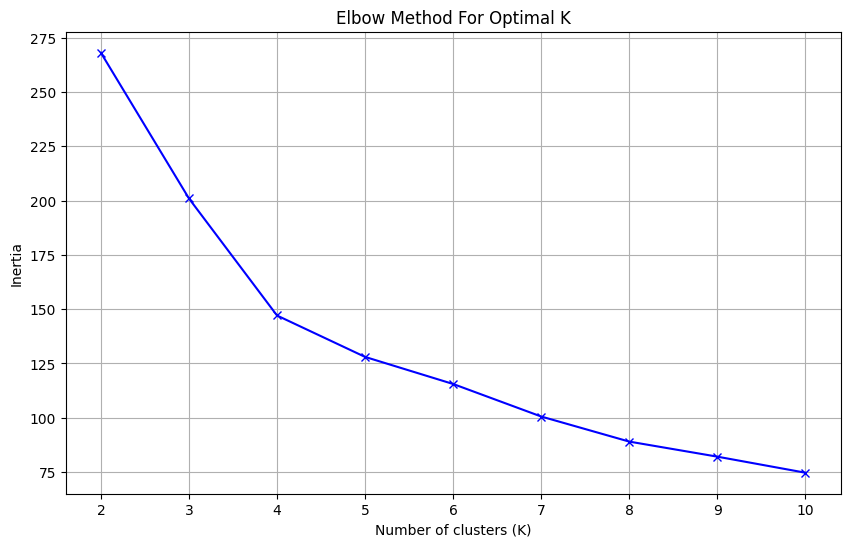

In [4]:
# K-Means 클러스터링을 위한 최적의 K 찾기
inertia = []
K = range(2, 11)  # 2개부터 10개까지의 클러스터 테스트

for k in K:
    kmeans_model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_model.fit(tfidf_matrix)
    inertia.append(kmeans_model.inertia_)

# 엘보우 그래프 시각화
plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal K')
plt.grid(True)
plt.show()

In [5]:
# 최적의 K로 K-Means 모델 생성 및 학습
optimal_k = 4 # 엘보우 메소드에서 찾은 값으로 변경하세요.
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(tfidf_matrix)

# 결과 데이터프레임에 클러스터 라벨 추가
customer_item_str['Taste_Cluster'] = clusters

# 각 클러스터의 특성 파악 (어떤 상품을 주로 구매하는가?)
print(f"--- K={optimal_k} 클러스터링 결과 ---")
for i in range(optimal_k):
    cluster_customers = customer_item_str[customer_item_str['Taste_Cluster'] == i]
    # 각 클러스터의 모든 구매 기록을 하나의 문자열로 합침
    all_items_in_cluster = ' '.join(cluster_customers['ProductCategory'])
    
    # 가장 많이 등장하는 단어(카테고리)를 통해 클러스터 특성 파악
    # 간단하게 value_counts()를 사용
    top_categories = pd.Series(all_items_in_cluster.split()).value_counts().nlargest(2)
    
    print(f"\n[Cluster {i}] - 총 {len(cluster_customers)}명")
    print("주요 구매 카테고리:")
    print(top_categories)

# 결과 확인
customer_item_str.head()

--- K=4 클러스터링 결과 ---

[Cluster 0] - 총 246명
주요 구매 카테고리:
가공식품      678
건강기능식품    365
Name: count, dtype: int64

[Cluster 1] - 총 298명
주요 구매 카테고리:
건강기능식품    977
가공식품      276
Name: count, dtype: int64

[Cluster 2] - 총 211명
주요 구매 카테고리:
건강기능식품    307
뷰티        306
Name: count, dtype: int64

[Cluster 3] - 총 241명
주요 구매 카테고리:
생활용품      521
건강기능식품    324
Name: count, dtype: int64


,CustomerID,ProductCategory,Taste_Cluster
0,C0001,가공식품 뷰티 건강기능식품 생활용품,2
1,C0002,생활용품 가공식품 가공식품 가공식품 건강기능식품,0
2,C0003,가공식품 건강기능식품 가공식품 가공식품,0
3,C0004,생활용품 생활용품,3
4,C0005,뷰티 건강기능식품 가공식품 건강기능식품,2


In [7]:
# 필요한 컬럼만 선택하여 저장
taste_cluster_df = customer_item_str[['CustomerID', 'Taste_Cluster']]

taste_cluster_df.to_csv('data/customer_taste_clusters.csv', index=False, encoding='utf-8-sig')

print("-" * 30)
print(f"✅ 소비패턴 클러스터링 완료! 결과가 저장되었습니다.")

------------------------------
✅ 소비패턴 클러스터링 완료! 결과가 저장되었습니다.
